
<img src="https://weclouddata.s3.amazonaws.com/images/logos/wcd_logo_new_2.png" width='30%'>

<h1 align="left"> End-to-end Baseline Model Exercise  </h1>
Delivered by WeCloudData
<br>

----------

# Exercise: Predict House Prices

Now it's your turn!

You will build a model to predict house prices based on features like:
- income
- number of rooms
- location

---

##  Goal:
Apply the same ML pipeline you just learned.

Supervised Regression:

**Data -> X/y -> train/test split -> fit model -> predict -> evaluate**

X = features

y = target

Regression target = continuous value

## Install & Import Libraries

##  Step 1: Import Libraries

 Try to recall from memory:
What libraries do we need?

In [1]:
# TODO: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

## Step 2: Load Data

We are using a built-in dataset from sklearn.

In [2]:
# TODO: Load dataset
data = fetch_california_housing(as_frame=True)


**bold text**## Step 3: Explore Data

Answer:
- What is the target column?
- What are the features?

In [3]:
df = pd.DataFrame(data.frame)

In [4]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [5]:
#df = data.frame
#df. # Displays the first few rows of the dataset to quickly inspect the data structure and content.

df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [6]:
#df.  # Prints a summary of the dataframe, including column data types, non-null counts, and memory usage.

df.info()
#df.   # Generates descriptive statistics (like mean, min, and max) to summarize the central tendency and dispersion of numerical columns.

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Step 4: Visualize Data

 Plot:
Median Income vs House Price

Question:
Do richer areas have higher house prices?

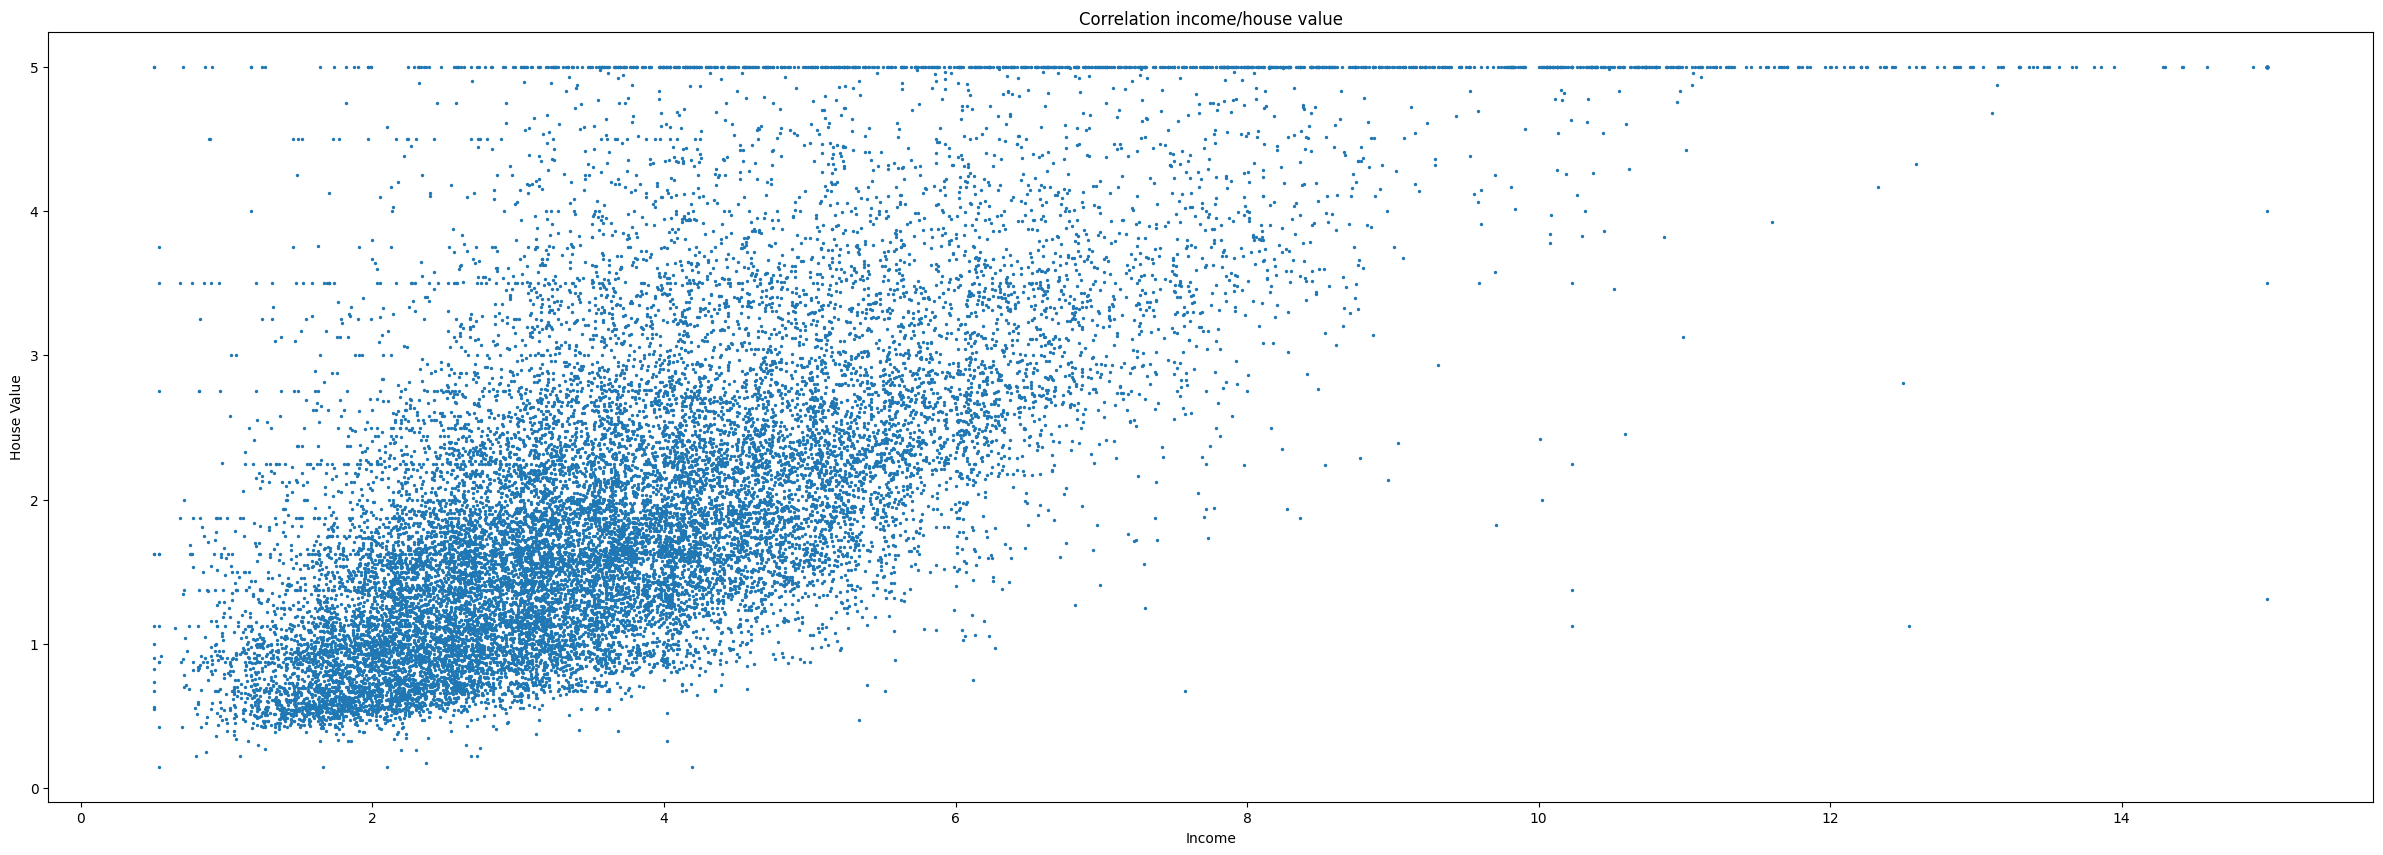

In [7]:
# TODO: Create scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize= (30,10))
plt.scatter(x = df["MedInc"], y = df["MedHouseVal"], s = 2) # Creates a scatter plot to visualize the relationship and correlation between two numerical variables.
plt.xlabel("Income") # Sets the label for the horizontal axis.
plt.ylabel("House Value") # Sets the label for the vertical axis.
plt.title("Correlation income/house value") # Adds a descriptive title to the top of the chart.
plt.show() # Displays the completed figure on the screen.

## Step 8: Define Features (X) and Target (y)

We split the dataset into:

X → Inputs (features)
y → Output (target)

This is what the model learns from.

In [8]:
# TODO:
X = df.drop("MedHouseVal", axis = 1)  #yourcode
y = df["MedHouseVal"]  #yourcode

##  Step 6: Split Data

We split data into:
- Training set → model learns from this
- Testing set → we evaluate performance

Why do we split data?

In [9]:
# TODO:
from sklearn.model_selection import train_test_split
 # Randomly splits the dataset into training (80%) and testing (20%) sets to evaluate model performance on unseen data.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle = True)


In [10]:
y_test

,MedHouseVal
20046,0.47700
3024,0.45800
15663,5.00001
20484,2.18600
9814,2.78000
...,...
15362,2.63300
16623,2.66800
18086,5.00001
2144,0.72300


##  Step 7: Train Model

This time we use:
Linear Regression

Question:
Why not Logistic Regression?

In [11]:
# TODO:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Step 8: Predictions

In [13]:
# TODO:
y_pred = model.predict(X_test)

## Step 9: Evaluate Model

For regression we use:
Mean Squared Error (MSE)

Lower = better

In [14]:
# TODO:
#from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.5558915986952444


#Compare Actual vs Predicted

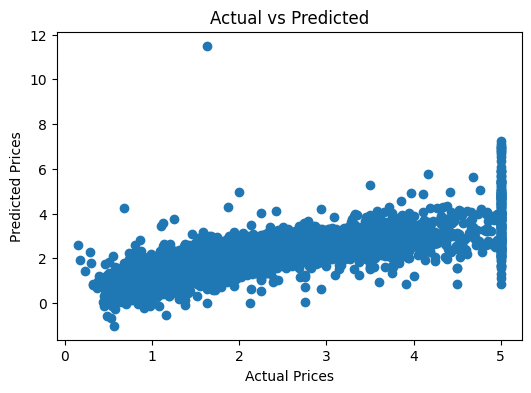

In [15]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

## Reflection

- Is the model accurate?
- What could improve it?

The model performed reasonably well, but there’s still room for improvement. Accuracy could be improved by using more data, better feature selection, tuning hyperparameters, or trying more advanced models instead of basic Linear Regression